___

# <font color= #EF4444> **Speech Radicalization Analysis** </font>
#### <font color= #f0565e> `Deep Learning`</font>
<Strong> Sofía Maldonado, Oscar Josué Rocha & Viviana Toledo </Strong>

_12/05/2026._

___

This notebook aims to visualize embeddings generated by our BERTweet model, based on the labels of each tweet.

# <font color= #EF4444> **Libraries & Data** </font>

In [101]:
# General
import pandas as pd
import numpy as np

# Visualization
import umap.umap_ as umap
import plotly.express as px
import plotly.io as pio

# Modeling
import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification

<Axes: title={'center': 'Tweet Labels'}>

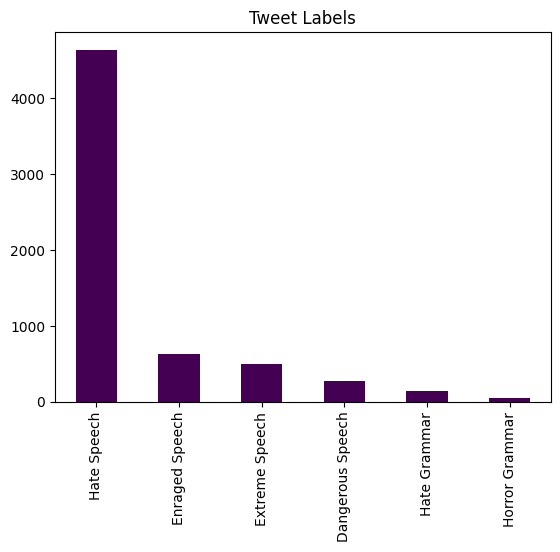

In [82]:
df = pd.read_csv('../data/processed/speech_classified.csv')
df = df[['clean_text', 'annotation_label']]

df['annotation_label'].value_counts().sort_values(ascending=False).plot(kind="bar", title="Tweet Labels", xlabel="", ylabel="", colormap="viridis")

As observed on the picture, the dataset is quite imbalanced. Let's load the predictions made by the BERTweet model based on our test set:

In [83]:
# Load model predictions
df_vis = pd.read_csv("../data/processed/test_predictions.csv")

# Get text
texts = df_vis["tweet"].tolist()

df_vis.head()

,tweet,true_label,predicted_label
0,the hair is giving,Hate Speech,Hate Speech
1,"if they don't like it, i'm sure someone would ...",Hate Speech,Hate Speech
2,hamas revives momentum for political bureau ch...,Hate Speech,Enraged Speech
3,"if you're not anti fascism, then you're not am...",Hate Speech,Hate Speech
4,for sedition against the constitution. by ally...,Hate Speech,Enraged Speech


# <font color= #EF4444> **Visualization** </font>

The visualization will represent the embeddings obtained by BERTweet on 2D and 3D on our test set. Firstly, we need to load the model's weights and tokenizer:

In [84]:
# Define model path
MODEL_PATH = "../models/results/checkpoint-1555"

# Load tokenizer
tokenizer = AutoTokenizer.from_pretrained(MODEL_PATH)
# Load model
model = AutoModelForSequenceClassification.from_pretrained(MODEL_PATH)

# Load model to GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

# Set model to evaluation mode
model.eval()

[transformers] emoji is not installed, thus not converting emoticons or emojis into text. Install emoji: pip3 install emoji==0.6.0
Loading weights: 100%|██████████| 201/201 [00:00<00:00, 12855.37it/s]


RobertaForSequenceClassification(
  (roberta): RobertaModel(
    (embeddings): RobertaEmbeddings(
      (word_embeddings): Embedding(64001, 768, padding_idx=1)
      (token_type_embeddings): Embedding(1, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
      (position_embeddings): Embedding(130, 768, padding_idx=1)
    )
    (encoder): RobertaEncoder(
      (layer): ModuleList(
        (0-11): 12 x RobertaLayer(
          (attention): RobertaAttention(
            (self): RobertaSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): RobertaSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
             

Since the model outputs a sequence of token embeddings (a matrix), we need to extract the semantic meaning of each embedding for UMAP. For this, we use a function to average the values of the embeddings, ignoring padding made to each embedding, which returns a single vector of 768 dimensions:

In [85]:
# Reduce embedding size
def mean_pooling(last_hidden_state, attention_mask):
    # Expand the embeddings
    mask = attention_mask.unsqueeze(-1).expand(last_hidden_state.size()).float()
    # Remove padding tokens
    masked = last_hidden_state * mask
    # Sum values
    summed = torch.sum(masked, dim=1)
    # Count real tokens
    counts = torch.clamp(mask.sum(dim=1), min=1e-9)
    # Calculate average
    return summed / counts

Next, we run the pipeline of encoding and tokenizing the tweets, extracting the semantic values of each one and storing it:

In [86]:
# Get embeddings by batch
batch_size = 32
all_embeddings = []

# Loop over dataset
for i in range(0, len(texts), batch_size):

    batch = texts[i:i+batch_size]
    
    # Encode tokens
    encoded = tokenizer(
        batch,
        padding=True,
        truncation=True,
        max_length=128,
        return_tensors="pt"
    )

    encoded = {k: v.to(device) for k, v in encoded.items()}


    with torch.no_grad():
        # Run BERTweet
        outputs = model.roberta(
            input_ids=encoded["input_ids"],
            attention_mask=encoded["attention_mask"],
            return_dict=True
        )
        # Convert embeddings to single-value vectors
        embeddings = mean_pooling(
            outputs.last_hidden_state,
            encoded["attention_mask"]
        )

    all_embeddings.append(embeddings.cpu().numpy())

# Store embeddings
embeddings = np.vstack(all_embeddings)

# Embeddings 
embeddings.shape

(1244, 768)

We have a total of 1244 embeddings, each representing a vector with 768 dimensions. Now, we can run an UMAP algorithm, let's start with the 2D version:

In [87]:
umap_2d = umap.UMAP(
    n_components=2,
    n_neighbors=10,
    min_dist=0.1,
    metric="cosine",
    random_state=42
)

umap_embeddings_2d = umap_2d.fit_transform(embeddings)

# Add embeddings to dataframe
df_vis["x_2d"] = umap_embeddings_2d[:, 0]
df_vis["y_2d"] = umap_embeddings_2d[:, 1]

/home/vivienne/apps/deep-learning/speech_radicalization_analysis/.venv/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


And using plotly, we can visualize the embeddings:

In [88]:
print(df_vis.columns)

Index(['tweet', 'true_label', 'predicted_label', 'x_2d', 'y_2d'], dtype='str')


In [103]:
fig = px.scatter(
    df_vis,
    x="x_2d",
    y="y_2d",

    color="predicted_label",

    hover_data={
        "tweet": True,
        "true_label": True,
        "predicted_label": True,
        "x_2d": False,
        "y_2d": False
    },

    title="BERTweet 2D UMAP Embeddings for the Test Set",

    width=1400,
    height=900
)

fig.update_traces(marker=dict(size=7, opacity=0.75))

fig.update_layout(
    xaxis_title="x",
    yaxis_title="y"
)

# Save visualization
fig.write_html("../reports/figures/embeddings_2d.html", include_plotlyjs="cdn")

fig.show()

Let's now visualize the embeddings in 3D, using the same parameters:

In [90]:
umap_3d = umap.UMAP(
    n_components=3,
    n_neighbors=10,
    min_dist=0.1,
    metric="cosine",
    random_state=42
)

umap_embeddings_3d = umap_3d.fit_transform(embeddings)

df_vis["x_3d"] = umap_embeddings_3d[:, 0]
df_vis["y_3d"] = umap_embeddings_3d[:, 1]
df_vis["z_3d"] = umap_embeddings_3d[:, 2]

/home/vivienne/apps/deep-learning/speech_radicalization_analysis/.venv/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


In [104]:
fig = px.scatter_3d(
    df_vis,
    x="x_3d",
    y="y_3d",
    z="z_3d",

    color="predicted_label",

    hover_data={
        "tweet": True,
        "true_label": True,
        "predicted_label": True,
        "x_3d": False,
        "y_3d": False,
        "z_3d": False
    },

    title="BERTweet 3D UMAP Embeddings for the Test Set",
    width=1600,
    height=800
)

fig.update_traces(marker=dict(size=4, opacity=0.75))

fig.update_layout(
    scene=dict(
        xaxis_title="x",
        yaxis_title="y",
        zaxis_title="z"
    )
)
# Save visualization
fig.write_html("../reports/figures/embeddings_3d.html", include_plotlyjs="cdn")

fig.show()